In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu, wilcoxon, spearmanr

df = pd.read_csv("all_chbmit_seizure_model_result_clean_common500.csv")
df = df[df["success"] == True].copy()

print(df.shape)
print(df["period"].value_counts())
print(df["patient"].nunique())
print(df["edf_file"].nunique())

(11682, 48)
period
interictal    9223
preictal      1296
postictal      913
ictal          250
Name: count, dtype: int64
14
74


In [2]:
period_means = (
    df.groupby("period")[["mu_est", "phi_est", "alpha_est", "gamma_est", "r_est"]]
      .median()
      .loc[["interictal", "preictal", "ictal", "postictal"]]
)

print(period_means)

              mu_est   phi_est  alpha_est  gamma_est     r_est
period                                                        
interictal -0.114550  0.228362  -4.041227  -0.062787  0.004753
preictal   -0.155540  0.219113  -5.079149  -0.029964  0.001240
ictal      -0.149271  0.585583  -2.416417   0.300549  0.048455
postictal  -0.157538  0.209359  -5.552718   0.011216  0.000986


In [3]:
quartiles = (
    df
    .groupby("period")["gamma_est"]
    .agg([
        ("n", "count"),
        ("q1", lambda x: x.quantile(0.25)),
        ("median", "median"),
        ("q3", lambda x: x.quantile(0.75)),
        ("iqr", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ])
)

display(quartiles)

,n,q1,median,q3,iqr
period,,,,,
ictal,250,-0.558586,0.300549,1.452253,2.010839
interictal,9223,-2.497642,-0.062787,1.167578,3.665220
postictal,913,-3.419777,0.011216,1.616900,5.036677
preictal,1296,-3.502676,-0.029964,1.446145,4.948821


In [38]:
patient_delta = (
    df.groupby("patient")["delta_bic_sv"]
      .median()
)

print(
    (patient_delta > 0).sum(),
    "/",
    len(patient_delta)
)

13 / 14


In [19]:
patient_delta = (
    df.groupby("patient")["bic_gamma0"]
      .median()
)

print(
    (patient_delta > 0).sum(),
    "/",
    len(patient_delta)
)

2 / 14


In [20]:
patient_delta = (
    df.groupby("patient")["delta_bic_gamma0"]
      .median()
)

print(
    (patient_delta > 0).sum(),
    "/",
    len(patient_delta)
)

2 / 14


In [21]:
from scipy.stats import wilcoxon
import numpy as np

patient_stage = (
    df.groupby(["patient", "period"])
    .agg(
        delta_nll_gamma0=("delta_nll_gamma0", "median"),
        delta_nll_sv=("delta_nll_sv", "median"),
        delta_bic_gamma0=("delta_bic_gamma0", "median"),
        delta_bic_sv=("delta_bic_sv", "median"),
    )
    .reset_index()
)

for var in ["delta_nll_gamma0", "delta_nll_sv","delta_bic_gamma0","delta_bic_sv"]:
    wide = patient_stage.pivot(index="patient", columns="period", values=var)

    for stage in ["interictal", "preictal", "ictal", "postictal"]:
        if stage not in wide.columns:
            continue

        vals = wide[stage].dropna()

        # Test whether median ΔNLL is greater than zero
        if len(vals) >= 3 and not np.allclose(vals, 0):
            stat, p = wilcoxon(vals, alternative="greater")
            print(var, stage, "n=", len(vals),
                  "median=", vals.median(),
                  "positive=", (vals > 0).sum(),
                  "p=", p)

delta_nll_gamma0 interictal n= 14 median= 1.2717062943973687 positive= 11 p= 0.0594482421875
delta_nll_gamma0 preictal n= 14 median= 1.702452914200375 positive= 12 p= 0.00042724609375
delta_nll_gamma0 ictal n= 14 median= 3.4543488184351716 positive= 14 p= 6.103515625e-05
delta_nll_gamma0 postictal n= 13 median= 0.6003351895038662 positive= 8 p= 0.2939453125
delta_nll_sv interictal n= 14 median= 1.6360133149777356 positive= 11 p= 0.0594482421875
delta_nll_sv preictal n= 14 median= 2.6029610405438888 positive= 12 p= 0.00115966796875
delta_nll_sv ictal n= 14 median= 3.689314168465984 positive= 13 p= 0.0001220703125
delta_nll_sv postictal n= 13 median= 1.4141586081066322 positive= 9 p= 0.3424072265625
delta_bic_gamma0 interictal n= 14 median= -1.5509319734273603 positive= 2 p= 0.9852294921875
delta_bic_gamma0 preictal n= 14 median= -0.6894387338213547 positive= 6 p= 0.61956787109375
delta_bic_gamma0 ictal n= 14 median= 2.8143530746482526 positive= 11 p= 0.0042724609375
delta_bic_gamma0 pos

In [59]:
wins_per_patient = (
    df.groupby(["patient", "joint_wins_gamma0"])
        .size()
        .reset_index(name="n_wins")
)

totals = (
    df.groupby("patient")
        .size()
        .reset_index(name="total_comparisons")
)

wins_per_patient = wins_per_patient.merge(totals, on="patient")
wins_per_patient["win_prop"] = (
    wins_per_patient["n_wins"] / wins_per_patient["total_comparisons"]
)

wins_per_patient = wins_per_patient.sort_values(
    ["patient", "win_prop"],
    ascending=[True, False]
)

wins_per_patient

,patient,joint_wins_gamma0,n_wins,total_comparisons,win_prop
1,chb01,True,376,724,0.519337
0,chb01,False,348,724,0.480663
3,chb02,True,146,171,0.853801
2,chb02,False,25,171,0.146199
4,chb04,False,590,904,0.652655
5,chb04,True,314,904,0.347345
6,chb05,False,146,239,0.610879
7,chb05,True,93,239,0.389121
9,chb06,True,2916,3415,0.853880
8,chb06,False,499,3415,0.146120


In [22]:
df["patient"].value_counts()

patient
chb06    3415
chb12    2432
chb10    1001
chb04     904
chb13     791
chb09     745
chb01     724
chb03     259
chb07     245
chb05     239
chb14     230
chb08     206
chb02     171
chb11     138
Name: count, dtype: int64

/tmp/ipykernel_353/3255528270.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("stage")[params]



Stage summaries:
           gamma_est                             phi_est                      \
              median      mean       std count    median      mean       std   
stage                                                                          
interictal -0.057830 -0.373288  2.983506  9091  0.230137  0.276830  0.321801   
preictal   -0.016884 -0.386405  3.236367  1269  0.218209  0.275268  0.311906   
ictal       0.305070  0.187325  2.641151   245  0.578231  0.585058  0.336396   
postictal   0.001638 -0.319827  3.274280   895  0.204608  0.249181  0.300943   

                     r_est                           alpha_est            \
           count    median      mean       std count    median      mean   
stage                                                                      
interictal  9091  0.005101  0.059987  0.909820  9091 -3.941799 -4.590681   
preictal    1269  0.001375  0.035745  0.117209  1269 -4.981799 -5.136053   
ictal        245  0.047399  0.240984  0.4

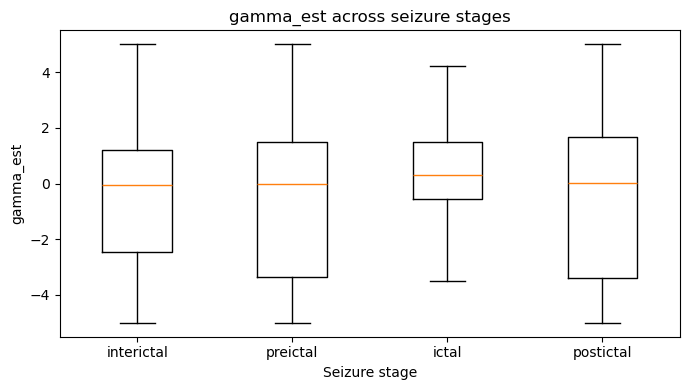

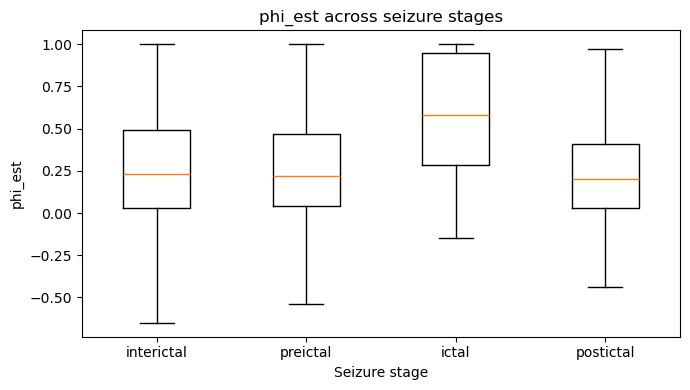

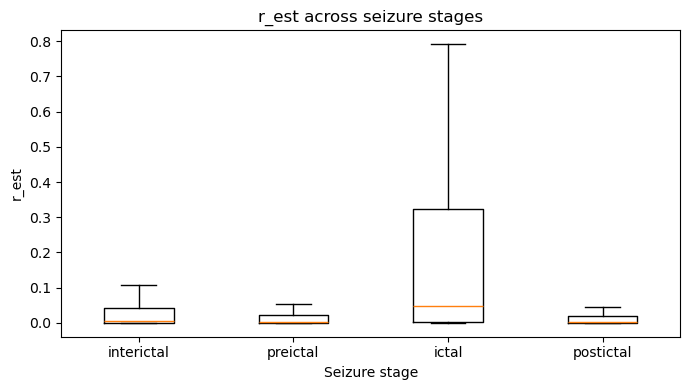

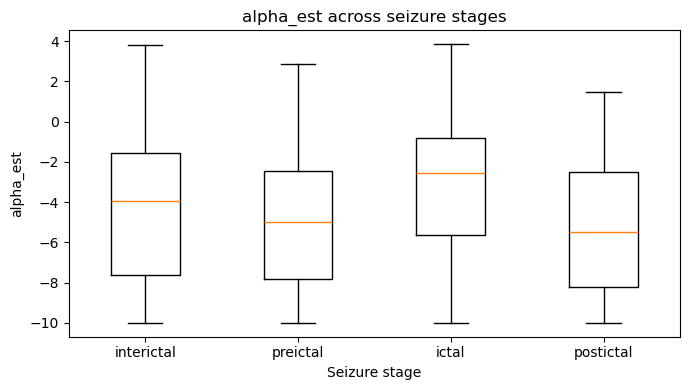

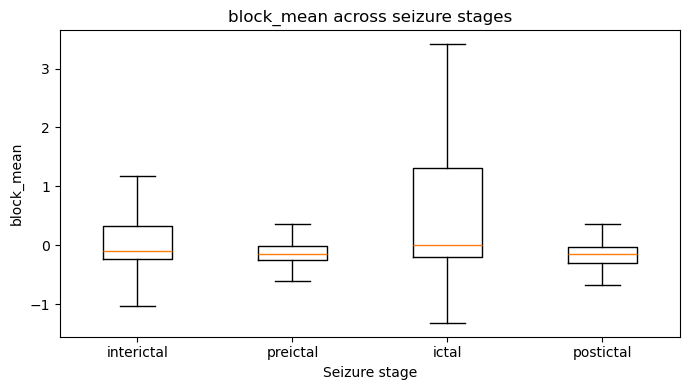

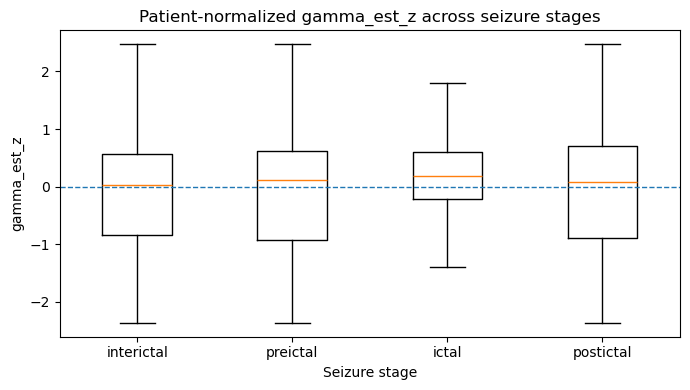

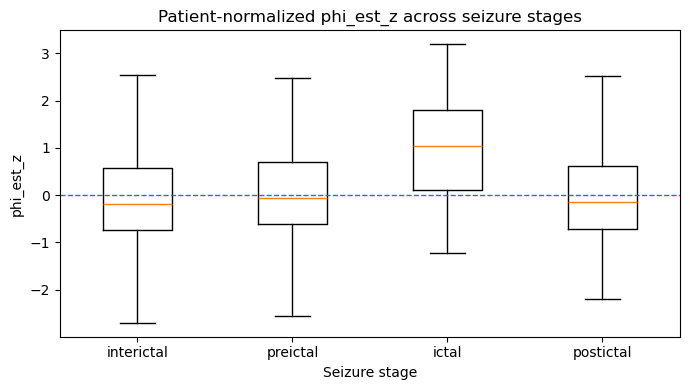

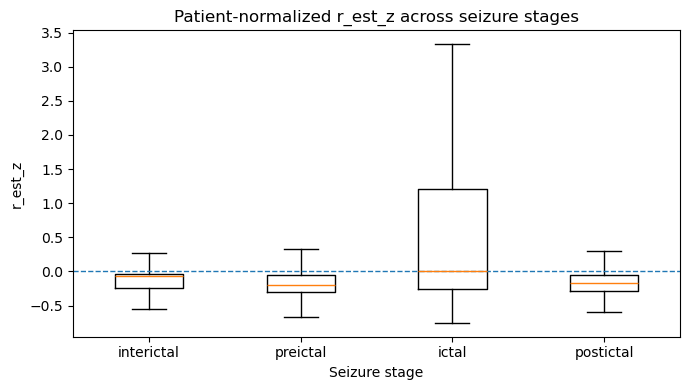

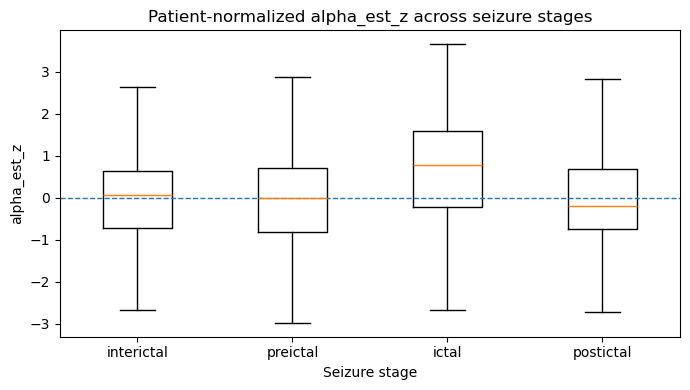

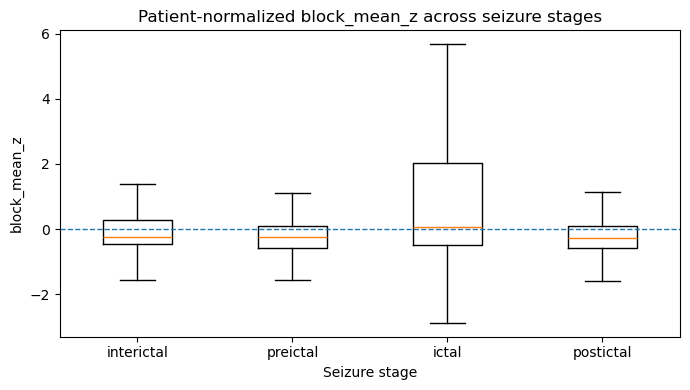


Patient-level consistency for gamma_est:
ictal > interictal: 13/14 patients
ictal > preictal: 11/14 patients
postictal > interictal: 8/13 patients
postictal > ictal: 3/13 patients

Patient-level consistency for phi_est:
ictal > interictal: 14/14 patients
ictal > preictal: 12/14 patients
postictal > interictal: 6/13 patients
postictal > ictal: 0/13 patients

Patient-level consistency for r_est:
ictal > interictal: 13/14 patients
ictal > preictal: 12/14 patients
postictal > interictal: 4/13 patients
postictal > ictal: 0/13 patients

Patient-level consistency for alpha_est:
ictal > interictal: 12/14 patients
ictal > preictal: 11/14 patients
postictal > interictal: 4/13 patients
postictal > ictal: 0/13 patients

Patient-level consistency for block_mean:
ictal > interictal: 11/14 patients
ictal > preictal: 11/14 patients
postictal > interictal: 3/13 patients
postictal > ictal: 3/13 patients

Paper-ready median table:
        stage  gamma_est   phi_est     r_est  alpha_est  block_mean
0  in

/tmp/ipykernel_353/3255528270.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["patient", "stage"])[params]
/tmp/ipykernel_353/3255528270.py:157: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("stage")[params]


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Expected columns:
# patient, stage, gamma_est, phi_est, r_est

stage_order = ["interictal", "preictal", "ictal", "postictal"]
params = ["gamma_est", "phi_est", "r_est","alpha_est","block_mean"]

df["stage"] = pd.Categorical(df["period"], categories=stage_order, ordered=True)

# -------------------------
# 1. Summary table
# -------------------------
summary = (
    df.groupby("stage")[params]
      .agg(["median", "mean", "std", "count"])
      .loc[stage_order]
)

print("\nStage summaries:")
print(summary)

# -------------------------
# 2. Kruskal-Wallis tests
# -------------------------
print("\nKruskal-Wallis tests:")

for param in params:
    groups = [
        df.loc[df["stage"] == stage, param].dropna()
        for stage in stage_order
    ]

    H, p = kruskal(*groups)

    print(f"{param}: H = {H:.3f}, p = {p:.3e}")

# -------------------------
# 3. Pairwise Mann-Whitney tests + Cliff's delta
# -------------------------
pairwise_results = []

for param in params:
    for i, s1 in enumerate(stage_order):
        for s2 in stage_order[i + 1:]:
            x = df.loc[df["stage"] == s1, param].dropna().values
            y = df.loc[df["stage"] == s2, param].dropna().values

            U, p = mannwhitneyu(x, y, alternative="two-sided")

            cliffs_delta = (
                np.sum(x[:, None] > y[None, :]) -
                np.sum(x[:, None] < y[None, :])
            ) / (len(x) * len(y))

            pairwise_results.append({
                "parameter": param,
                "comparison": f"{s1} vs {s2}",
                "median_1": np.median(x),
                "median_2": np.median(y),
                "p_raw": p,
                "cliffs_delta": cliffs_delta
            })

pairwise = pd.DataFrame(pairwise_results)
pairwise["p_fdr"] = multipletests(pairwise["p_raw"], method="fdr_bh")[1]

print("\nPairwise results:")
print(pairwise.sort_values(["parameter", "p_fdr"]))

pairwise.to_csv("stage_pairwise_results.csv", index=False)
summary.to_csv("stage_summary_results.csv")

# -------------------------
# 4. Boxplots by stage
# -------------------------
for param in params:
    data = [
        df.loc[df["stage"] == stage, param].dropna()
        for stage in stage_order
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data, labels=stage_order, showfliers=False)

    plt.xlabel("Seizure stage")
    plt.ylabel(param)
    plt.title(f"{param} across seizure stages")
    plt.tight_layout()
    plt.savefig(f"{param}_by_stage_boxplot.png", dpi=300)
    plt.show()

# -------------------------
# 5. Patient-normalized plots
# -------------------------
df_norm = df.copy()

for param in params:
    df_norm[param + "_z"] = (
        df_norm[param] -
        df_norm.groupby("patient")[param].transform("mean")
    ) / df_norm.groupby("patient")[param].transform("std")

for param in [p + "_z" for p in params]:
    data = [
        df_norm.loc[df_norm["stage"] == stage, param].dropna()
        for stage in stage_order
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data, labels=stage_order, showfliers=False)
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xlabel("Seizure stage")
    plt.ylabel(param)
    plt.title(f"Patient-normalized {param} across seizure stages")
    plt.tight_layout()
    plt.savefig(f"{param}_by_stage_boxplot.png", dpi=300)
    plt.show()

# -------------------------
# 6. Patient-level consistency
# -------------------------
patient_stage = (
    df.groupby(["patient", "stage"])[params]
      .median()
      .reset_index()
)

wide = patient_stage.pivot(index="patient", columns="stage", values=params)

for param in params:
    print(f"\nPatient-level consistency for {param}:")

    for s1, s2 in [
        ("interictal", "ictal"),
        ("preictal", "ictal"),
        ("interictal", "postictal"),
        ("ictal", "postictal"),
    ]:
        valid = wide[param][[s1, s2]].dropna()

        n_total = len(valid)
        n_direction = (valid[s2] > valid[s1]).sum()

        print(f"{s2} > {s1}: {n_direction}/{n_total} patients")

# -------------------------
# 7. Simple paper-ready table
# -------------------------
paper_table = (
    df.groupby("stage")[params]
      .median()
      .loc[stage_order]
      .reset_index()
)

print("\nPaper-ready median table:")
print(paper_table)

In [26]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal, wilcoxon



stage_col = "stage" if "stage" in df.columns else "period"

# Baseline process variance at latent center
df["q_center"] = np.exp(np.clip(df["alpha_est"], -20, 10))

# Model-implied process variance at fixed latent distances from mu
for d in [0.5, 1.0, 2.0]:
    label = str(d).replace(".", "p")
    df[f"q_dist_{label}"] = np.exp(
        np.clip(df["alpha_est"] + df["gamma_est"] * d, -20, 10)
    )
    df[f"q_multiplier_{label}"] = np.exp(
        np.clip(df["gamma_est"] * d, -20, 10)
    )

# Exploratory observed-block proxy, not exact q_t
df["q_block_mean_proxy"] = np.exp(
    np.clip(
        df["alpha_est"]
        + df["gamma_est"] * np.abs(df["block_mean"] - df["mu_est"]),
        -20,
        10,
    )
)

In [27]:
summary = (
    df.groupby(stage_col)
    .agg(
        n=("q_center", "size"),
        median_q_center=("q_center", "median"),
        mean_q_center=("q_center", "mean"),
        median_q_dist_1=("q_dist_1p0", "median"),
        mean_q_dist_1=("q_dist_1p0", "mean"),
        median_q_multiplier_1=("q_multiplier_1p0", "median"),
        mean_q_multiplier_1=("q_multiplier_1p0", "mean"),
        median_q_block_mean_proxy=("q_block_mean_proxy", "median"),
        median_gamma=("gamma_est", "median"),
        median_alpha=("alpha_est", "median"),
    )
    .reset_index()
)

print(summary)

        stage     n  median_q_center  mean_q_center  median_q_dist_1  \
0  interictal  9091         0.019413       0.225810         0.051482   
1    preictal  1269         0.006862       0.161395         0.011581   
2       ictal   245         0.078906       1.440081         0.234548   
3   postictal   895         0.004193       0.156627         0.013516   

   mean_q_dist_1  median_q_multiplier_1  mean_q_multiplier_1  \
0       0.243257               0.943810            18.236775   
1       0.211122               0.983258            21.495130   
2       1.050117               1.356720            16.754669   
3       0.193898               1.001639            23.195690   

   median_q_block_mean_proxy  median_gamma  median_alpha  
0                   0.022647     -0.057830     -3.941799  
1                   0.007628     -0.016884     -4.981799  
2                   0.109775      0.305070     -2.539494  
3                   0.004445      0.001638     -5.474339  


/tmp/ipykernel_353/234534273.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(stage_col)


In [28]:
for var in ["q_center", "q_dist_1p0", "q_multiplier_1p0", "q_block_mean_proxy"]:
    groups = [
        g[var].dropna().values
        for _, g in df.groupby(stage_col)
        if len(g[var].dropna()) > 0
    ]
    H, p = kruskal(*groups)
    print(var, "Kruskal H =", H, "p =", p)

q_center Kruskal H = 111.83964321041455 p = 4.409612192879656e-24
q_dist_1p0 Kruskal H = 98.05010777355585 p = 4.080535693904977e-21
q_multiplier_1p0 Kruskal H = 13.544099068606345 p = 0.003596212715692631
q_block_mean_proxy Kruskal H = 140.38046778087383 p = 3.1291288028628118e-30


/tmp/ipykernel_353/2961685068.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in df.groupby(stage_col)


In [29]:
patient_stage = (
    df.groupby(["patient", stage_col])
    .agg(
        q_center=("q_center", "median"),
        q_dist_1=("q_dist_1p0", "median"),
        q_multiplier_1=("q_multiplier_1p0", "median"),
        q_block_mean_proxy=("q_block_mean_proxy", "median"),
        gamma=("gamma_est", "median"),
    )
    .reset_index()
)

print(patient_stage.head())

  patient       stage  q_center  q_dist_1  q_multiplier_1  q_block_mean_proxy  \
0   chb01  interictal  0.000109  0.000061        1.057417            0.000109   
1   chb01    preictal  0.000073  0.000048        0.906100            0.000073   
2   chb01       ictal  0.004348  0.064509        1.127636            0.007528   
3   chb01   postictal  0.000117  0.000118        1.093797            0.000117   
4   chb02  interictal  0.019716  0.000614        0.026857            0.018157   

      gamma  
0  0.055829  
1 -0.098606  
2  0.120124  
3  0.089652  
4 -3.619851  


/tmp/ipykernel_353/3088432679.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["patient", stage_col])


In [36]:
def paired_stage_test(patient_stage, value_col, ref="pretictal"):
    stages = sorted(patient_stage[stage_col].unique())
    out = []

    wide = patient_stage.pivot(
        index="patient",
        columns=stage_col,
        values=value_col
    )

    for stage in stages:
        if stage == ref or stage not in wide.columns or ref not in wide.columns:
            continue

        paired = wide[[ref, stage]].dropna()

        

        stat, p = wilcoxon(paired[stage], paired[ref])

        out.append({
            "value": value_col,
            "comparison": f"{stage} vs {ref}",
            "n_patients": len(paired),
            "median_ref": paired[ref].median(),
            "median_stage": paired[stage].median(),
            "median_difference": (paired[stage] - paired[ref]).median(),
            "n_positive": int((paired[stage] > paired[ref]).sum()),
            "p_value": p,
        })

    return pd.DataFrame(out)

results = pd.concat([
    paired_stage_test(patient_stage, "q_center"),
    paired_stage_test(patient_stage, "q_dist_1"),
    paired_stage_test(patient_stage, "q_multiplier_1"),
    paired_stage_test(patient_stage, "q_block_mean_proxy"),
], ignore_index=True)

print(results)

Empty DataFrame
Columns: []
Index: []


In [31]:
patient_stage = (
    df.groupby(["patient", stage_col])
    .agg(
        n_windows=("q_center", "size"),
        q_center=("q_center", "median"),
        q_dist_1=("q_dist_1p0", "median"),
        q_multiplier_1=("q_multiplier_1p0", "median"),
        q_block_mean_proxy=("q_block_mean_proxy", "median"),
        gamma=("gamma_est", "median"),
        phi=("phi_est", "median"),
        r=("r_est", "median"),
        alpha=("alpha_est", "median"),
    )
    .reset_index()
)

print(patient_stage)

   patient       stage  n_windows  q_center  q_dist_1  q_multiplier_1  \
0    chb01  interictal        484  0.000109  0.000061        1.057417   
1    chb01    preictal        161  0.000073  0.000048        0.906100   
2    chb01       ictal          9  0.004348  0.064509        1.127636   
3    chb01   postictal         70  0.000117  0.000118        1.093797   
4    chb02  interictal        138  0.019716  0.000614        0.026857   
5    chb02    preictal         25  0.036030  0.015350        0.364616   
6    chb02       ictal          8  1.317373  1.593399        1.113120   
7    chb02   postictal          0       NaN       NaN             NaN   
8    chb03  interictal        194  0.022024  0.046317        0.975226   
9    chb03    preictal         44  0.001312  0.000148        1.084944   
10   chb03       ictal          1  0.411655  0.645159        1.567233   
11   chb03   postictal         20  0.007166  0.030267        1.104135   
12   chb04  interictal        862  0.000045  0.0000

/tmp/ipykernel_353/2226883234.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["patient", stage_col])


In [32]:
wide = patient_stage.pivot(
    index="patient",
    columns="stage",
    values="q_center"
)

print(wide)
print("Non-missing counts by stage:")
print(wide.notna().sum())

print("Patients with interictal + ictal:")
print(wide[["interictal", "ictal"]].dropna() if "ictal" in wide.columns else "No ictal column")

stage    interictal  preictal     ictal  postictal
patient                                           
chb01      0.000109  0.000073  0.004348   0.000117
chb02      0.019716  0.036030  1.317373        NaN
chb03      0.022024  0.001312  0.411655   0.007166
chb04      0.000045  0.000603  0.713230   0.000045
chb05      0.000045  0.000102  0.306636   0.000065
chb06      0.230884  0.279777  0.221212   0.183840
chb07      0.010543  0.023665  1.447226   0.000045
chb08      0.155896  0.089342  0.058978   0.017706
chb09      0.000089  0.000070  0.027466   0.000045
chb10      0.006958  0.062941  0.626622   0.001814
chb11      0.011862  0.610857  2.471136   0.001557
chb12      0.009263  0.005503  0.014140   0.008495
chb13      0.000903  0.001901  0.001133   0.000740
chb14      0.007228  0.025327  0.144132   0.034802
Non-missing counts by stage:
stage
interictal    14
preictal      14
ictal         14
postictal     13
dtype: int64
Patients with interictal + ictal:
stage    interictal     ictal
pati

In [5]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedGroupKFold


CSV = "all_chbmit_seizure_model_result_clean_common500.csv"


def make_features(df):
    df = df.copy()

    # Model-implied process variance summaries
    df["q_center"] = np.exp(np.clip(df["alpha_est"], -20, 10))
    df["q_dist_1"] = np.exp(np.clip(df["alpha_est"] + df["gamma_est"], -20, 10))
    df["q_multiplier_1"] = np.exp(np.clip(df["gamma_est"], -20, 10))

    feature_cols = [
        "alpha_est",
        "phi_est",
        "gamma_est",
        "block_mean",
        "block_sd"
    ]

    return df, feature_cols


def grouped_auc(df, label_col, feature_cols, n_splits=5):
    X = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    y = df[label_col].astype(int).values
    groups = df["patient"].values

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ])

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=123,
    )

    pred = np.full(len(df), np.nan)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        if len(np.unique(y[train_idx])) < 2:
            continue

        model.fit(X.iloc[train_idx], y[train_idx])
        pred[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]

    valid = np.isfinite(pred)

    auc = roc_auc_score(y[valid], pred[valid])
    auprc = average_precision_score(y[valid], pred[valid])

    return {
        "label": label_col,
        "n": int(valid.sum()),
        "positive_rate": float(y[valid].mean()),
        "auc": float(auc),
        "auprc": float(auprc),
    }, pred


def main():
    df = pd.read_csv(CSV)

    # Keep successful fits only
    df = df[df["success"].astype(str).str.lower().isin(["true", "1"])].copy()

    # Use period as seizure-stage label
    df["period"] = df["period"].astype(str)

    df, feature_cols = make_features(df)

    print("Rows:", len(df))
    print("Patients:", df["patient"].nunique())
    print("Stage counts:")
    print(df["period"].value_counts())
    print("Features:", feature_cols)

    # Binary labels
    df["ictal_vs_nonictal"] = (df["period"] == "ictal").astype(int)

    df["periictal_vs_interictal"] = (
        df["period"].isin(["preictal", "ictal", "postictal"])
    ).astype(int)

    df["preictal_vs_interictal"] = np.nan
    mask_pre = df["period"].isin(["preictal", "interictal"])
    df.loc[mask_pre, "preictal_vs_interictal"] = (
        df.loc[mask_pre, "period"] == "preictal"
    ).astype(int)

    df["ictal_vs_interictal"] = np.nan
    mask_ictal = df["period"].isin(["ictal", "interictal"])
    df.loc[mask_ictal, "ictal_vs_interictal"] = (
        df.loc[mask_ictal, "period"] == "ictal"
    ).astype(int)

    tasks = [
        ("ictal_vs_nonictal", df),
        ("periictal_vs_interictal", df),
        ("preictal_vs_interictal", df[mask_pre].copy()),
        ("ictal_vs_interictal", df[mask_ictal].copy()),
    ]

    results = []

    for label_col, dsub in tasks:
        dsub = dsub.dropna(subset=[label_col]).copy()

        # Need both classes and enough patients
        if dsub[label_col].nunique() < 2 or dsub["patient"].nunique() < 3:
            print("Skipping", label_col, "not enough classes/patients")
            continue

        n_splits = min(5, dsub["patient"].nunique())

        res, pred = grouped_auc(
            dsub,
            label_col=label_col,
            feature_cols=feature_cols,
            n_splits=n_splits,
        )

        results.append(res)

        # Save predictions for inspection
        dsub[f"pred_{label_col}"] = pred
        dsub[
            ["patient", "edf_file", "seizure_id", "channel", "block",
             "period", label_col, f"pred_{label_col}"] + feature_cols
        ].to_csv(f"auc_predictions_{label_col}.csv", index=False)

    results_df = pd.DataFrame(results)
    print(results_df)
    results_df.to_csv("auc_latent_feature_results.csv", index=False)


if __name__ == "__main__":
    main()

Rows: 11682
Patients: 14
Stage counts:
period
interictal    9223
preictal      1296
postictal      913
ictal          250
Name: count, dtype: int64
Features: ['alpha_est', 'phi_est', 'gamma_est', 'block_mean', 'block_sd']
                     label      n  positive_rate       auc     auprc
0        ictal_vs_nonictal  11682       0.021400  0.681692  0.118964
1  periictal_vs_interictal  11682       0.210495  0.474494  0.192839
2   preictal_vs_interictal  10519       0.123206  0.412340  0.096836
3      ictal_vs_interictal   9473       0.026391  0.667151  0.077396


In [4]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedGroupKFold


CSV = "all_chbmit_seizure_model_result_clean_common500.csv"


def make_features(df):
    df = df.copy()

    # Model-implied process variance summaries
    df["q_center"] = np.exp(np.clip(df["alpha_est"], -20, 10))
    df["q_dist_1"] = np.exp(np.clip(df["alpha_est"] + df["gamma_est"], -20, 10))
    df["q_multiplier_1"] = np.exp(np.clip(df["gamma_est"], -20, 10))

    feature_cols = [
        "block_mean",
        "block_sd",
        
    ]

    return df, feature_cols


def grouped_auc(df, label_col, feature_cols, n_splits=5):
    X = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    y = df[label_col].astype(int).values
    groups = df["patient"].values

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ])

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=123,
    )

    pred = np.full(len(df), np.nan)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        if len(np.unique(y[train_idx])) < 2:
            continue

        model.fit(X.iloc[train_idx], y[train_idx])
        pred[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]

    valid = np.isfinite(pred)

    auc = roc_auc_score(y[valid], pred[valid])
    auprc = average_precision_score(y[valid], pred[valid])

    return {
        "label": label_col,
        "n": int(valid.sum()),
        "positive_rate": float(y[valid].mean()),
        "auc": float(auc),
        "auprc": float(auprc),
    }, pred


def main():
    df = pd.read_csv(CSV)

    # Keep successful fits only
    df = df[df["success"].astype(str).str.lower().isin(["true", "1"])].copy()

    # Use period as seizure-stage label
    df["period"] = df["period"].astype(str)

    df, feature_cols = make_features(df)

    print("Rows:", len(df))
    print("Patients:", df["patient"].nunique())
    print("Stage counts:")
    print(df["period"].value_counts())
    print("Features:", feature_cols)

    # Binary labels
    df["ictal_vs_nonictal"] = (df["period"] == "ictal").astype(int)

    df["periictal_vs_interictal"] = (
        df["period"].isin(["preictal", "ictal", "postictal"])
    ).astype(int)

    df["preictal_vs_interictal"] = np.nan
    mask_pre = df["period"].isin(["preictal", "interictal"])
    df.loc[mask_pre, "preictal_vs_interictal"] = (
        df.loc[mask_pre, "period"] == "preictal"
    ).astype(int)

    df["ictal_vs_interictal"] = np.nan
    mask_ictal = df["period"].isin(["ictal", "interictal"])
    df.loc[mask_ictal, "ictal_vs_interictal"] = (
        df.loc[mask_ictal, "period"] == "ictal"
    ).astype(int)

    tasks = [
        ("ictal_vs_nonictal", df),
        ("periictal_vs_interictal", df),
        ("preictal_vs_interictal", df[mask_pre].copy()),
        ("ictal_vs_interictal", df[mask_ictal].copy()),
    ]

    results = []

    for label_col, dsub in tasks:
        dsub = dsub.dropna(subset=[label_col]).copy()

        # Need both classes and enough patients
        if dsub[label_col].nunique() < 2 or dsub["patient"].nunique() < 3:
            print("Skipping", label_col, "not enough classes/patients")
            continue

        n_splits = min(5, dsub["patient"].nunique())

        res, pred = grouped_auc(
            dsub,
            label_col=label_col,
            feature_cols=feature_cols,
            n_splits=n_splits,
        )

        results.append(res)

        # Save predictions for inspection
        dsub[f"pred_{label_col}"] = pred
        dsub[
            ["patient", "edf_file", "seizure_id", "channel", "block",
             "period", label_col, f"pred_{label_col}"] + feature_cols
        ].to_csv(f"auc_predictions_{label_col}.csv", index=False)

    results_df = pd.DataFrame(results)
    print(results_df)
    results_df.to_csv("auc_latent_feature_results.csv", index=False)


if __name__ == "__main__":
    main()

Rows: 11682
Patients: 14
Stage counts:
period
interictal    9223
preictal      1296
postictal      913
ictal          250
Name: count, dtype: int64
Features: ['block_mean', 'block_sd']
                     label      n  positive_rate       auc     auprc
0        ictal_vs_nonictal  11682       0.021400  0.693159  0.092429
1  periictal_vs_interictal  11682       0.210495  0.479132  0.193444
2   preictal_vs_interictal  10519       0.123206  0.458082  0.104456
3      ictal_vs_interictal   9473       0.026391  0.676064  0.078599
